# ERA5 Analysis of Hurricane Ida's Impacts on New York City

---

## Overview
This notebook consists of:

1. Prerequisites
1. Prepping Data
1. Plotting Data
1. Summary
2. Resources / References


## Prerequisites (unsure yet)
This section was inspired by [this template](https://github.com/alan-turing-institute/the-turing-way/blob/master/book/templates/chapter-template/chapter-landing-page.md) of the wonderful [The Turing Way](https://the-turing-way.netlify.app) Jupyter Book.

Following your overview, tell your reader what concepts, packages, or other background information they'll **need** before learning your material. Tie this explicitly with links to other pages here in Foundations or to relevant external resources. Remove this body text, then populate the Markdown table, denoted in this cell with `|` vertical brackets, below, and fill out the information following. In this table, lay out prerequisite concepts by explicitly linking to other Foundations material or external resources, or describe generally helpful concepts.

Label the importance of each concept explicitly as **helpful/necessary**.

| Concepts | Importance | Notes |
| --- | --- | --- |
| [Intro to Cartopy](https://foundations.projectpythia.org/core/cartopy/cartopy) | Necessary | |
| [Understanding of NetCDF](https://foundations.projectpythia.org/core/data-formats/netcdf-cf) | Helpful | Familiarity with metadata structure |
| Project management | Helpful | |

- **Time to learn**: estimate in minutes. For a rough idea, use 5 mins per subsection, 10 if longer; add these up for a total. Safer to round up and overestimate.
- **System requirements**:
    - Populate with any system, version, or non-Python software requirements if necessary
    - Otherwise use the concepts table above and the Imports section below to describe required packages as necessary
    - If no extra requirements, remove the **System requirements** point altogether

---

## Imports
Begin your body of content with another `---` divider before continuing into this section, then remove this body text and populate the following code cell with all necessary Python imports **up-front**:

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
from datetime import datetime as dt
from metpy.units import units
import metpy.calc as mpcalc
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

## Prepping Data

This is where you begin your first section of material, loosely tied to your objectives stated up front. Tie together your notebook as a narrative, with interspersed Markdown text, images, and more as necessary,

In [5]:
# Areal extent

lonW = -80
lonE = -65
latS = 39
latN = 48
cLat, cLon = (latS + latN)/2, (lonW + lonE)/2

# Recall that in ERA5, longitudes run between 0 and 360, not -180 and 180
if (lonW < 0 ):
    lonW = lonW + 360
if (lonE < 0 ):
    lonE = lonE + 360
    
expand = 1
latRange = np.arange(latS - expand,latN + expand,.25) # expand the data range a bit beyond the plot range
lonRange = np.arange((lonW - expand),(lonE + expand),.25) # Need to match longitude values to those of the coordinate variable

# Vertical level specificaton
plevel = 500
levelStr = str(plevel)

# Date/Time specification
Year = 2021
Month = 9
Day = 1
Hour = 00
Minute = 0
dateTime = dt(Year,Month,Day, Hour)
timeStr = dateTime.strftime("%Y-%m-%d %H%M UTC")
timeStr

'2021-09-01 0000 UTC'

In [6]:
%%time 
use_DE = True
#use_DE = False
if (use_DE):
  ds = xr.open_dataset(
  'https://data.earthdatahub.destine.eu/era5/reanalysis-era5-pressure-levels-v0.zarr', 
  chunks={}, storage_options={"client_kwargs":{"trust_env":True}}, consolidated=True, engine="zarr"
  )

else:
    ds = xr.open_dataset(
    'gs://weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721.zarr', 
     chunks = {'time':48}, consolidated = True, engine="zarr"
    )
print(f'size: {ds.nbytes / (1024 ** 4)} TB')

size: 863.106730104857 TB
CPU times: user 86.1 ms, sys: 15 ms, total: 101 ms
Wall time: 1.5 s


In [7]:
ds

<xarray.Dataset> Size: 949TB
Dimensions:        (valid_time: 751680, isobaricInhPa: 19, latitude: 721,
                    longitude: 1440)
Coordinates:
  * isobaricInhPa  (isobaricInhPa) int32 76B 1000 925 850 700 600 ... 20 10 5 1
  * latitude       (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude      (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    number         int64 8B ...
  * valid_time     (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-09-30T...
Data variables: (12/16)
    cc             (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    ciwc           (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    clwc           (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    crwc           (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    cswc           (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    d              (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    ...             ...
    t              (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    u              (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    v              (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    vo             (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    w              (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    z              (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-11-15T16:05 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

### Data Subsetting / Unit Conversions


In [8]:
%%time 
if (use_DE):
    z = ds['z'].sel(valid_time=dateTime,isobaricInhPa=plevel,latitude=latRange,longitude=lonRange)
else:
    z = ds['geopotential'].sel(time=dateTime,level=plevel,latitude=latRange,longitude=lonRange)

z

CPU times: user 8.72 s, sys: 440 ms, total: 9.16 s
Wall time: 9.19 s


<xarray.DataArray 'z' (latitude: 44, longitude: 68)> Size: 12kB
dask.array<getitem, shape=(44, 68), dtype=float32, chunksize=(44, 68), chunktype=numpy.ndarray>
Coordinates:
    isobaricInhPa  int32 4B 500
  * latitude       (latitude) float64 352B 38.0 38.25 38.5 ... 48.25 48.5 48.75
  * longitude      (longitude) float64 544B 279.0 279.2 279.5 ... 295.5 295.8
    number         int64 8B ...
    valid_time     datetime64[ns] 8B 2021-09-01
Attributes: (12/31)
    GRIB_NV:                                  0
    GRIB_Nx:                                  1440
    GRIB_Ny:                                  721
    GRIB_cfName:                              geopotential
    GRIB_cfVarName:                           z
    GRIB_dataType:                            an
    ...                                       ...
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_units:                               m**2 s**-2
    GRIB_uvRelativeToGrid:                    0
    long_name:                                Geopotential
    standard_name:                            geopotential
    units:                                    m**2 s**-2

In [9]:
lats = z.latitude
lons = z.longitude

In [10]:
z = mpcalc.geopotential_to_height(z).metpy.convert_units('dam')

## Plotting


In [11]:
proj_map = ccrs.LambertConformal(central_longitude=156, central_latitude=20)
proj_data = ccrs.PlateCarree() # Our data is lat-lon; thus its native projection is Plate Carree.
res = '50m'

In [12]:
minVal = 474
maxVal = 606
cint = 6
Zcintervals = np.arange(minVal, maxVal, cint)
Zcintervals

array([474, 480, 486, 492, 498, 504, 510, 516, 522, 528, 534, 540, 546,
       552, 558, 564, 570, 576, 582, 588, 594, 600])

In [13]:
tl1 = f"ERA5 {levelStr} hPa heights (dam, contour lines)"
tl2 = f"Valid at: {timeStr}"
title_line = (tl1 + '\n' + tl2 + '\n')

TypeError: Length of x (44) must match number of columns in z (68)

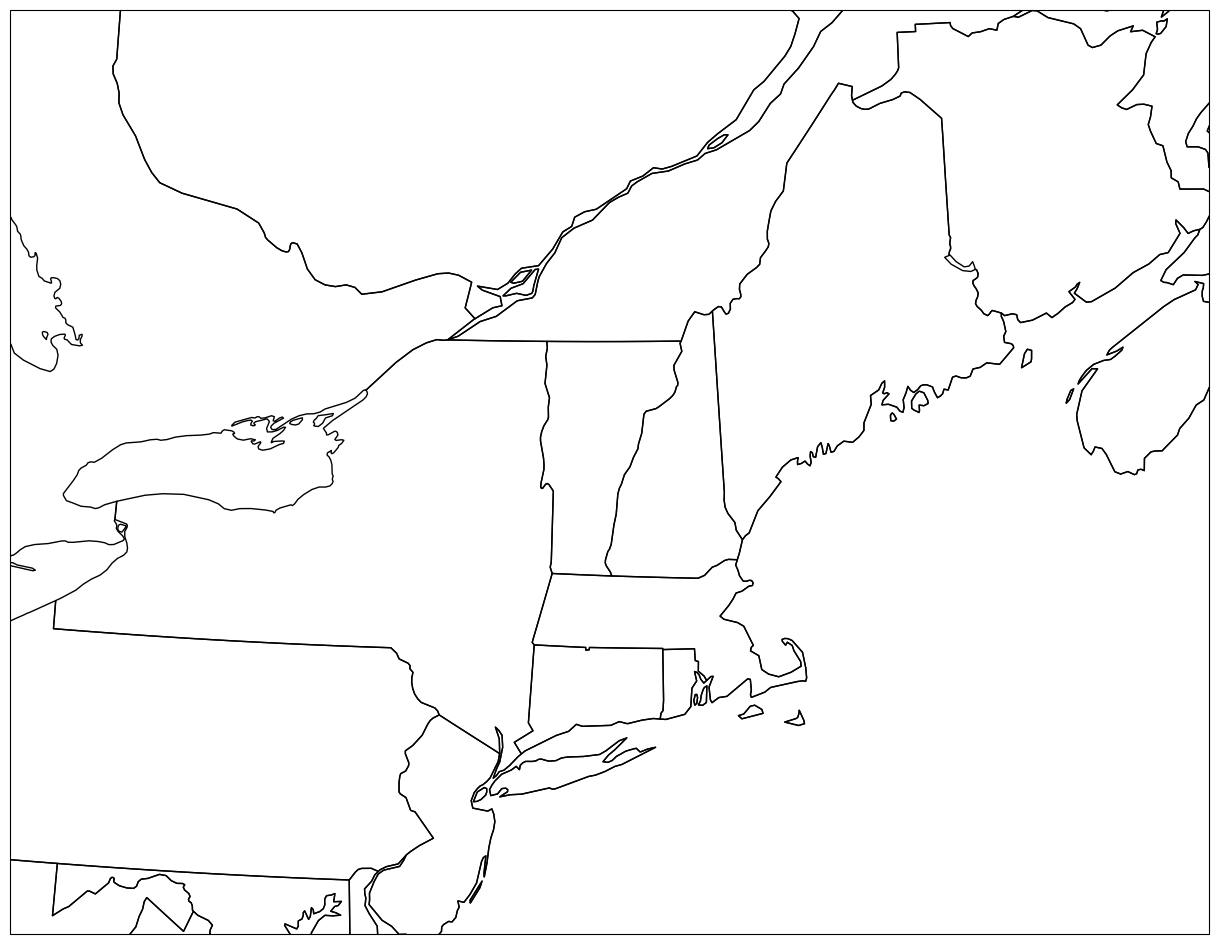

In [14]:
proj_map = ccrs.LambertConformal(central_longitude=cLon, central_latitude=cLat)
proj_data = ccrs.PlateCarree()
res = '50m'
fig = plt.figure(figsize=(18,12))
ax = plt.subplot(1,1,1,projection=proj_map)
ax.set_extent ([lonW,lonE,latS,latN])
ax.add_feature(cfeature.COASTLINE.with_scale(res))
ax.add_feature(cfeature.STATES.with_scale(res))
CL = ax.contour(z.latitude, z.longitude, z, levels=Zcintervals,transform=proj_data,linewidths=1.25, colors='green')
ax.clabel(CL, inline_spacing=0.2, fontsize=11, fmt='%.0f')
title = plt.title(title_line,fontsize=16)

### Potentially helpful markdown notes for the future:

:::{note}
Your relevant information here!
:::

Some other admonitions you can put in ([there are 10 total](https://mystmd.org/guide/admonitions#admonitions-list)):

:::{hint}
A helpful hint.
:::

:::{warning}
Be careful!
:::

:::{danger}
Scary stuff be here.
:::

---

## Summary (not enough work done to change, will do that as project goes along)




## Resources and references
Finally, be rigorous in your citations and references as necessary. Give credit where credit is due. Also, feel free to link to relevant external material, further reading, documentation, etc. Then you're done! Give yourself a quick review, a high five, and send us a pull request. A few final notes:
 - `Kernel > Restart Kernel and Run All Cells...` to confirm that your notebook will cleanly run from start to finish
 - `Kernel > Restart Kernel and Clear All Outputs...` before committing your notebook, our machines will do the heavy lifting
 - Take credit! Provide author contact information if you'd like; if so, consider adding information here at the bottom of your notebook
 - Give credit! Attribute appropriate authorship for referenced code, information, images, etc.
 - Only include what you're legally allowed: **no copyright infringement or plagiarism**
 
Thank you for your contribution!